In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sample_a = pd.read_csv('data/ab_test-redesign_sample_a.csv')
sample_b = pd.read_csv('data/ab_test-redesign_sample_b.csv')

In [3]:
sample_a.head()

,date,cid,transactions,revenue,group
0,2020-11-06,1.001648e+09,0,0,A
1,2020-11-06,1.001936e+09,0,0,A
2,2020-11-06,1.003214e+08,0,0,A
3,2020-11-06,1.004393e+09,0,0,A
4,2020-11-06,1.006382e+09,0,0,A


In [4]:
sample_b.head()

,date,cid,transactions,revenue,group
0,2020-11-06,1.000135e+09,0,0,B
1,2020-11-06,1.001648e+09,0,0,B
2,2020-11-06,1.003214e+08,0,0,B
3,2020-11-06,1.003652e+09,0,0,B
4,2020-11-06,1.003833e+09,0,0,B


In [5]:
sample_a['date'] = pd.to_datetime(sample_a['date'], format='%Y-%m-%d')
sample_b['date'] = pd.to_datetime(sample_a['date'], format='%Y-%m-%d')

In [6]:
dayly_sample_a = sample_a.groupby('date').agg({
    'cid': 'count',
    'transactions': 'sum',
    'revenue': 'sum'
}).reset_index().rename(columns={'cid': 'users_count'})

dayly_sample_b = sample_b.groupby('date').agg({
    'cid': 'count',
    'transactions': 'sum',
    'revenue': 'sum'
}).reset_index().rename(columns={'cid': 'users_count'})

dayly_sample_a.head()

,date,users_count,transactions,revenue
0,2020-11-06,2576,16,1577279
1,2020-11-07,2704,23,1721886
2,2020-11-08,3354,25,846051
3,2020-11-09,3234,18,708830
4,2020-11-10,3022,29,826984


In [7]:
mask = dayly_sample_a['date'] == '2020-11-08'
dayly_sample_a[mask]

,date,users_count,transactions,revenue
2,2020-11-08,3354,25,846051


In [8]:
dayly_sample_a['cum_users_count'] = dayly_sample_a['users_count'].cumsum()
dayly_sample_a['cum_transactions'] = dayly_sample_a['transactions'].cumsum()
dayly_sample_a['cum_revenue'] = dayly_sample_a['revenue'].cumsum()
dayly_sample_a['cum_conversion'] = dayly_sample_a['cum_transactions'] / dayly_sample_a['cum_users_count'] * 100
dayly_sample_a['cum_avg_check'] = dayly_sample_a['cum_revenue'] / dayly_sample_a['cum_users_count']

dayly_sample_b['cum_users_count'] = dayly_sample_b['users_count'].cumsum()
dayly_sample_b['cum_transactions'] = dayly_sample_b['transactions'].cumsum()
dayly_sample_b['cum_revenue'] = dayly_sample_b['revenue'].cumsum()
dayly_sample_b['cum_conversion'] = dayly_sample_b['cum_transactions'] / dayly_sample_b['cum_users_count'] * 100
dayly_sample_b['cum_avg_check'] = dayly_sample_b['cum_revenue'] / dayly_sample_b['cum_users_count']

In [12]:
print(dayly_sample_a['cum_conversion'].mean())
print(dayly_sample_b['cum_conversion'].mean())

0.7127554606160046
0.7677097512163391


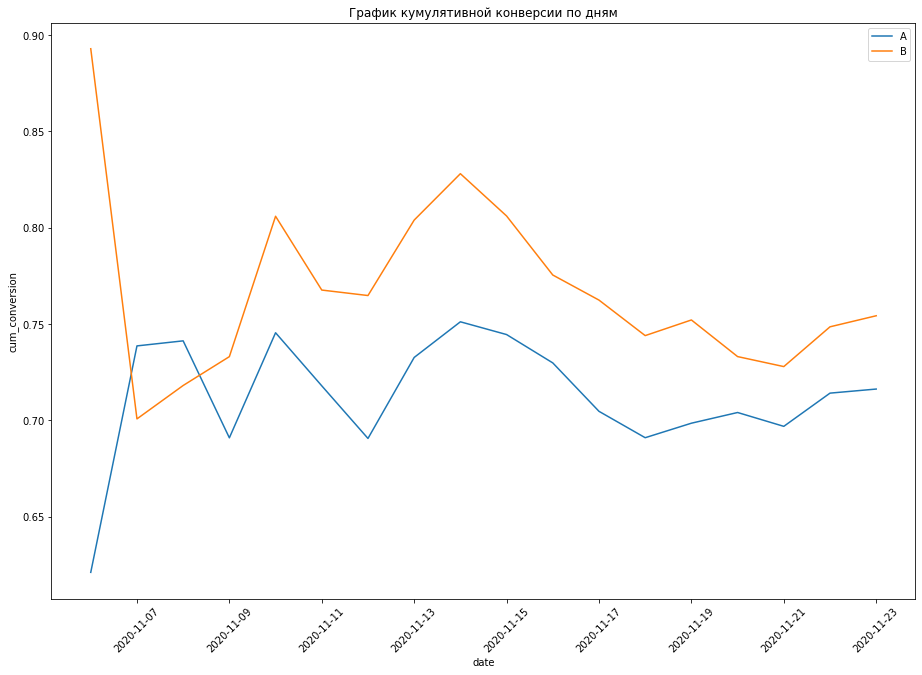

In [27]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_axes([1, 1, 1, 1])

sns.lineplot(
    data=dayly_sample_a, 
    x='date', 
    y='cum_conversion',
    ax=ax
)

sns.lineplot(
    data=dayly_sample_b, 
    x='date', 
    y='cum_conversion',
    ax=ax
)

ax.set_title('График кумулятивной конверсии по дням')
ax.xaxis.set_tick_params(rotation = 45)
ax.legend(['A', 'B'])
lineplot_a.grid(True);

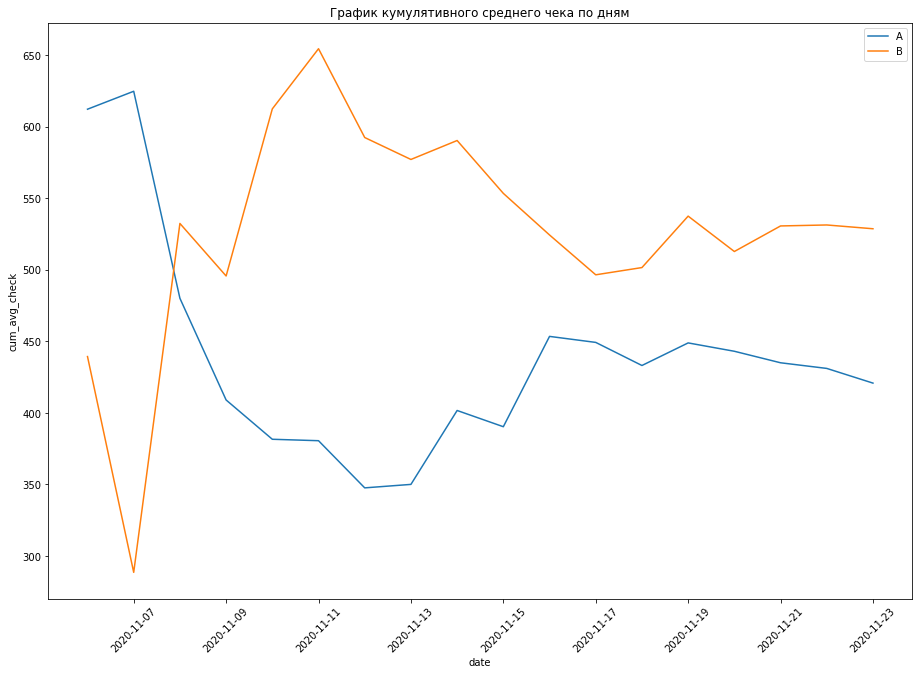

In [28]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_axes([1, 1, 1, 1])

sns.lineplot(
    data=dayly_sample_a, 
    x='date', 
    y='cum_avg_check',
    ax=ax
)

sns.lineplot(
    data=dayly_sample_b, 
    x='date', 
    y='cum_avg_check',
    ax=ax
)

ax.set_title('График кумулятивного среднего чека по дням')
ax.xaxis.set_tick_params(rotation = 45)
ax.legend(['A', 'B'])
lineplot_a.grid(True);

In [32]:
sample = pd.concat([sample_a, sample_b], axis=0)

piv_sample = sample.groupby('group')['transactions'].agg(['sum', 'count'])
piv_sample

,sum,count
group,,
A,441,61571
B,463,61383


In [34]:
from statsmodels.stats.proportion import proportions_ztest

# нулевая и альтернативная гипотезы
H0 = 'Конверсии в группах А и B равны'
H1 = 'Конверсия в группе А меньше, чем конверсия в группе B'
alpha = 0.1 # уровень значимости

# вычисляем значение p-value для z-теста для пропорций
_, p_value = proportions_ztest(
    count=piv_sample['sum'], #число "успехов"
    nobs=piv_sample['count'], #общее число наблюдений
    alternative='smaller',
)

# выводим результат на экран
print('p-value: ', round(p_value, 2))
# сравниваем полученное p-value с уровнем значимости
if (p_value < alpha): 
    print("Отвергаем нулевую гипотезу. {}".format(H0))
    print("Альтернативная гипотеза. H1: {}".format(H1))
else:
    print("Принимаем нулевую гипотезу. {}".format(H0))

p-value:  0.22
Принимаем нулевую гипотезу. Конверсии в группах А и B равны


In [42]:
from scipy.stats import mannwhitneyu

# нулевая и альтернативная гипотезы
H0 = 'Ежедневные средние чеки равны'
H1 = 'Ежедневный средний чек в группе А меньше, чем в группе B'
alpha = 0.1 # уровень значимости

# вычисляем результат теста Манна-Уитни
_, p_value = mannwhitneyu(
    dayly_sample_a['cum_avg_check'], 
    dayly_sample_b['cum_avg_check'],
    alternative='less'
)

print('p-value =', round(p_value, 2))

# сравниваем полученное p-value с уровнем значимости
if p_value < alpha:
    print("Отвергаем нулевую гипотезу. {}".format(H0))
    print("Альтернативная гипотеза. H1: {}".format(H1))
else:
    print("Принимаем нулевую гипотезу. {}".format(H0))

p-value = 0.0
Отвергаем нулевую гипотезу. Ежедневные средние чеки равны
Альтернативная гипотеза. H1: Ежедневный средний чек в группе А меньше, чем в группе B
